/tmp/ipykernel_4160664/210474836.py:52: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=250, annotation=500,limit=[-2000, -500])
/tmp/ipykernel_4160664/210474836.py:53: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(grid=grid, interval=50, annotation=50,limit=[-56, -49], pen="0.5p,blue,--",label_placement="d3c")


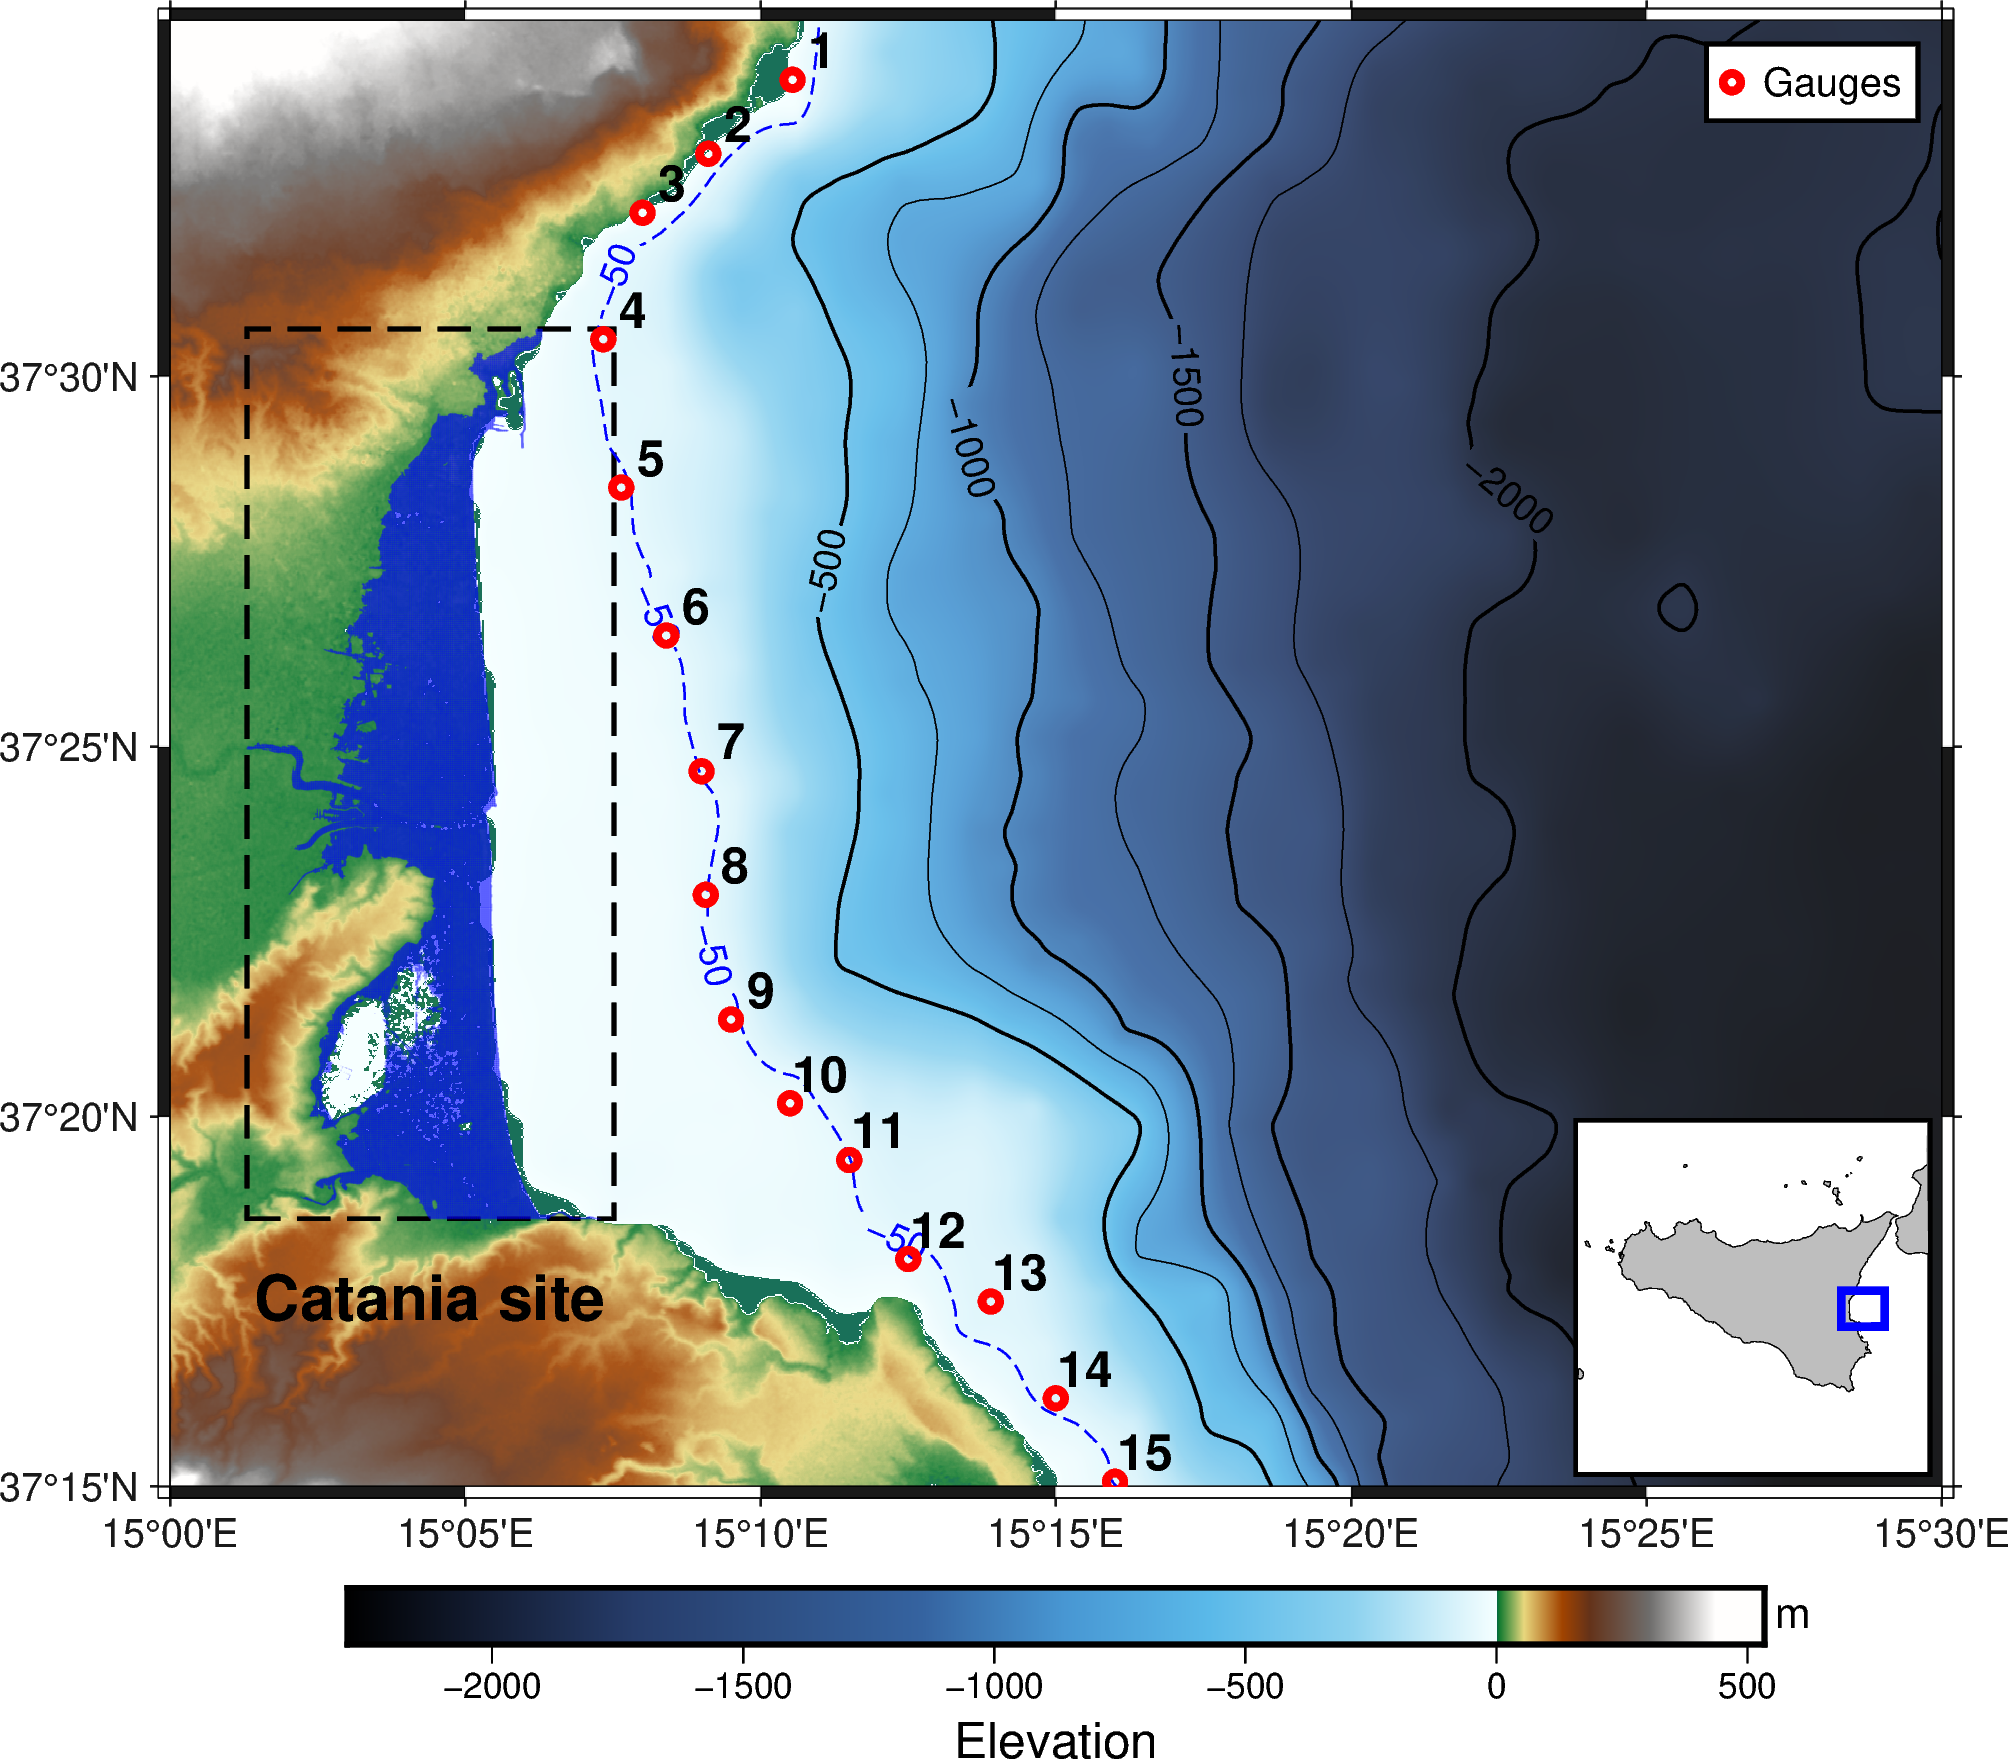

In [31]:
import pygmt
import xarray as xr
import pandas as pd
import numpy as np

#main plot region
region=[15, 15.5,37.25, 37.58]

#read grid lat lon info from text file
grid_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_CT_1658.txt',sep=',')
#add columns name
grid_info.columns = ['m','n','lat','lon']

# Load the grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')

grid = pygmt.datasets.load_earth_relief(
    resolution="01s", region=region, registration="gridline"
)

#read offshore points from 
gauges = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/pois_depth.csv',sep=',')

CT_gauges = list(range(30,50))

#combine both
selected_gauges =  gauges.iloc[CT_gauges]

fig = pygmt.Figure()

fig.grdimage(grid=grid, frame="a", projection="M15c", cmap="geo",transparency=10,shading=False)

#plot CT and SR grids area as rectangles
fig.plot(
    data = np.array([[float(grid_CT['x'].min().values),
                    float(grid_CT['y'].min().values),
                    float(grid_CT['x'].max()),
                    float(grid_CT['y'].max())]]),
    style='r+s',
    pen= "1p,black,-",)

#plot grids from text file
fig.plot(
        x = grid_info['lon'],
        y = grid_info['lat'],
        transparency=90,
        style="s0.0022c",
        pen="0.005p,blue",
)

# fig.coast(shorelines="2p,gray",region=[14.9, 15.5,37.25, 37.5888],frame="a", projection="M15c",)
fig.grdcontour(grid=grid, interval=250, annotation=500,limit=[-2000, -500])
fig.grdcontour(grid=grid, interval=50, annotation=50,limit=[-56, -49], pen="0.5p,blue,--",label_placement="d3c")

fig.plot(
    x=selected_gauges['lon'],
    y=selected_gauges['lat'],
    style="c0.15",
    pen="2p,red",
    label="Gauges ",
)

#add annotations for gauges
for i in range(len(selected_gauges)):
    fig.text(
        x=selected_gauges['lon'].iloc[i],
        y=selected_gauges['lat'].iloc[i],
        text=selected_gauges['id'].iloc[i]-31,
        font="12p,Helvetica-Bold,black",
        justify="CM",
        offset="0.25c",
    )

fig.text(
    x=15.07,    
    y=37.29,
    text="Catania site",
    font="15p,Helvetica-Bold,black",
    justify="CM",
    offset="0.1c",
)

with fig.inset(position="jBR+w3c/3c+o0.1c", box="+gwhite+p1p"):
    # Plot the Sicily main land in the inset using coast. "U54S/M?" means UTM
    # projection with map width automatically determined from the inset width.
    # Highlight the Japan area in "lightbrown"
    # and draw its outline with a pen of "0.2p".
    fig.coast(
        region=[12, 16, 36, 39],
        projection="U33S/?",
        dcw="IT+ggrey+p0.2p",
        area_thresh=10000,
    )
    # Plot a rectangle ("r") in the inset map to show the area of the main figure.
    # "+s" means that the first two columns are the longitude and latitude of
    # the bottom left corner of the rectangle, and the last two columns the
    # longitude and latitude of the uppper right corner.
    rectangle = [[region[0], region[2], region[1], region[3]]]
    fig.plot(data=rectangle, style="r+s", pen="2p,blue")

fig.colorbar(frame=["a500", "x+lElevation", "y+lm"])
fig.legend()
fig.savefig('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/plots/dtgeo/Catania.png',dpi=300)
fig.show()


/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/CT_deformation.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/CT_flowdepth.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/CT_height.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/C_CT.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/C_SR.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/SR_deformation.nc
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002/SR_flowdepth.nc
/mnt/be

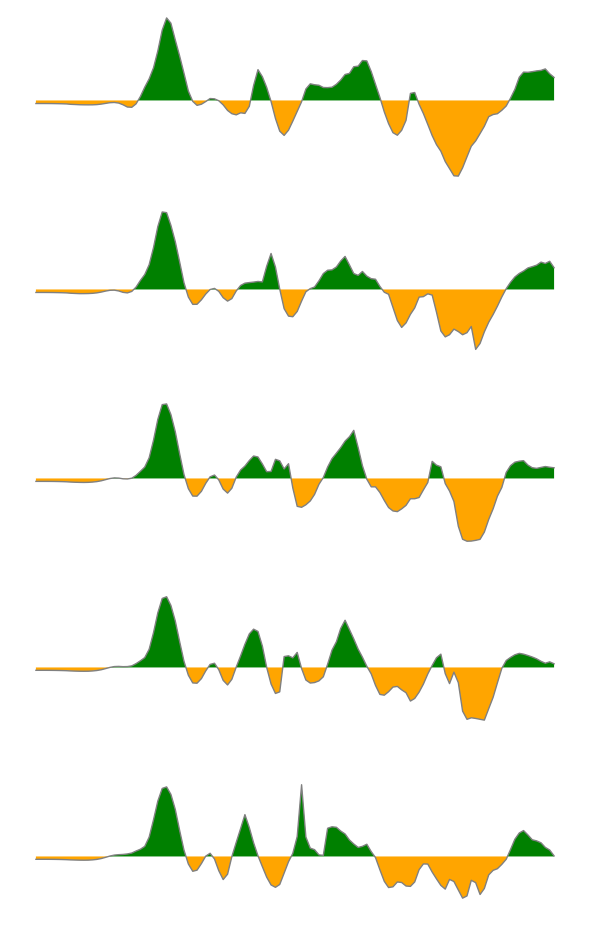

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

sim_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu'

reg = 'CT'
if reg == 'CT':
    eve_list = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv'
elif reg == 'SR':
    eve_list = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_SR_54.csv'

#load file in pandas
eve = pd.read_csv(eve_list,sep = ',')
eve_row = 878 #starts from 0
eve_id = eve['id'][eve_row]

eve_id = 'PS_manning003/E01548N3896E01854N3659-PS-Str_PYes_Hom-M861_E01793N3787_S002' #big ps

#read the file in one of the sim event folder
eve_path = os.path.join(sim_dir,eve_id)
file_list = glob.glob(eve_path + '/*.nc')
file_list.sort()
print(*file_list,sep = "\n")
# print('')
# for i in range(len(file_list)):
#     print(file_list[i])
#     ds = xr.open_dataset(file_list[i])
#     print(ds)


# Set up the figure and axes
fig, ax = plt.subplots(5, 1, figsize=(6, 10), sharex=True, sharey=True)

# Customize the style
plt.style.use('seaborn-v0_8-colorblind')

ds = xr.open_dataset(file_list[-1])
# Loop through the data
start = 37
for i in range(37, 42):
    print(i)
    # Plot the data
    ax[i - start].plot(ds.time[:120], ds.eta[:120, i], label=f'id:{i}', color='grey', linewidth=1)

    # Set axis off
    ax[i - start].set_axis_off()

    # Fill values above and below 0 with color
    ax[i - start].fill_between(ds.time[:120], ds.eta[:120, i], 0, where=ds.eta[:120, i] > 0, facecolor='green', interpolate=True)
    ax[i - start].fill_between(ds.time[:120], ds.eta[:120, i], 0, where=ds.eta[:120, i] < 0, facecolor='orange', interpolate=True)

# Adjust layout to prevent clipping of titles
fig.tight_layout(rect=[0, 0, 1, 0.96])

#save as svg with transparent background
plt.savefig('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/plots/dtgeo/eta.png', transparent=True, alpha=0.8)

# Display the plot
plt.show()



In [8]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

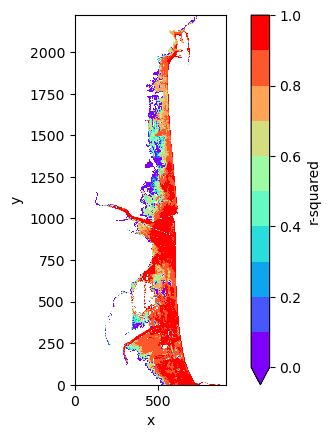

In [42]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
grid_CT_P1 = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r_squared_test.nc',engine='netcdf4')
data = grid_CT_P1['r-squared']
from matplotlib.colors import Normalize

norm = Normalize(vmin=0, vmax=1)
cmpa = plt.get_cmap('rainbow', 10)
data.plot(cmap=cmpa, norm=norm)

plt.gca().set_aspect('equal', adjustable='box')


#count non nan values
non_nan_count = np.count_nonzero(~np.isnan(data))

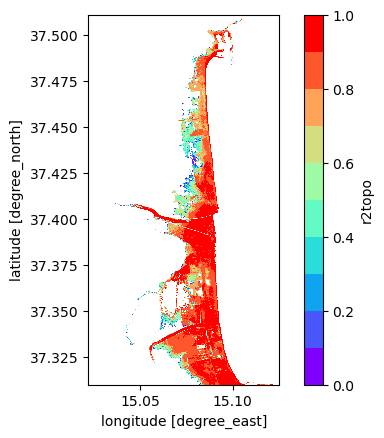

In [52]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
grid_CT_P1 = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2_topo_test.nc',engine='netcdf4')
data = grid_CT_P1['r2topo']
from matplotlib.colors import Normalize

#set values less than 0 to nan and greater than 1 to nan
data = data.where(data < 1, np.nan)
data = data.where(data > 0, np.nan)

norm = Normalize(vmin=0, vmax=1)
cmpa = plt.get_cmap('rainbow', 10)
data.plot(cmap=cmpa, norm=norm)
plt.gca().set_aspect('equal', adjustable='box')

#count non nan values
non_nan_count = np.count_nonzero(~np.isnan(data))